In [ ]:
import pandas as pd
df = pd.read_csv("rollrcoast.csv")
df

,RANK,#,TOWER,ACRONYM,WLD,AREA,DIFFICULTY,NUM,TIME,TIME [s],COMPLETION DATE
0,303,296,Tower of Genesis,ToG,1,Ring 00,[01]-[Easy],1.00,8:56.39,536.39,2025/10/27 14:51:23
1,296,65,Tower of Six Feet Under,ToSFU,2,Zone 03,[01]-[Easy],1.05,9:58.07,598.07,2022/10/23 12:57:42
2,323,7,Steeple of Beginner's Journey,SoBJ,1,Ring 02B,[01]-[Easy],1.11,5:17.88,317.88,2022/05/15 15:43:51
3,302,13,Tower of Zero Disturbances,ToZD,2,Zone 01,[01]-[Easy],1.15,8:59.69,539.69,2022/05/18 20:31:30
4,316,6,Steeple of Meaningless Decisions,SoMD,1,Ring 01B,[01]-[Easy],1.22,7:06.56,426.56,2022/05/15 15:24:05
...,...,...,...,...,...,...,...,...,...,...,...
320,161,308,Tower of Uncontrollable Ire,ToUI,2,Zone 07,[07]-[Remorseless],7.71,28:27.54,1707.54,2025/11/07 19:31:38
321,206,294,Tower of No Return,ToNR,2,Zone 08,[07]-[Remorseless],7.73,22:12.09,1332.09,2025/10/11 19:04:55
322,228,286,Tower of Rhythm Heaven,ToRH,1,Ring 06B,[07]-[Remorseless],7.74,18:22.68,1102.68,2025/08/12 23:42:03
323,144,287,Tower of Mechanical Disarray,ToMD,1,Ring 06B,[07]-[Remorseless],7.79,30:28.34,1828.34,2025/08/31 16:05:15


In [ ]:
print(df["TIME"])

0       8:56.39
1       9:58.07
2       5:17.88
3       8:59.69
4       7:06.56
         ...   
320    28:27.54
321    22:12.09
322    18:22.68
323    30:28.34
324    80:53.58
Name: TIME, Length: 325, dtype: str


In [ ]:
print(df.dtypes)

RANK                 int64
#                    int64
TOWER                  str
ACRONYM                str
WLD                  int64
AREA                   str
DIFFICULTY             str
NUM                float64
TIME                   str
TIME [s]           float64
COMPLETION DATE        str
dtype: object


<Axes: xlabel='NUM', ylabel='TIME [s]'>

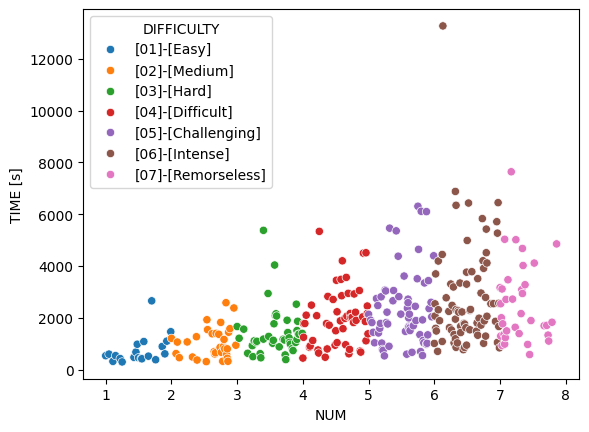

In [ ]:
import seaborn as sns

sns.scatterplot(data=df,x="NUM",y="TIME [s]",hue="DIFFICULTY")



In [ ]:
times = df["TIME [s]"]

print(times)

q1=times.quantile(0.25)
q3=times.quantile(0.75)
iqr = q3-q1

iqr

0       536.39
1       598.07
2       317.88
3       539.69
4       426.56
        ...   
320    1707.54
321    1332.09
322    1102.68
323    1828.34
324    4853.58
Name: TIME [s], Length: 325, dtype: float64


np.float64(1558.93)

In [ ]:
dg = df[(times < q3 + 1.5 * iqr) & (times > q1 - 1.5 * iqr)]

dg

,RANK,#,TOWER,ACRONYM,WLD,AREA,DIFFICULTY,NUM,TIME,TIME [s],COMPLETION DATE
0,303,296,Tower of Genesis,ToG,1,Ring 00,[01]-[Easy],1.00,8:56.39,536.39,2025/10/27 14:51:23
1,296,65,Tower of Six Feet Under,ToSFU,2,Zone 03,[01]-[Easy],1.05,9:58.07,598.07,2022/10/23 12:57:42
2,323,7,Steeple of Beginner's Journey,SoBJ,1,Ring 02B,[01]-[Easy],1.11,5:17.88,317.88,2022/05/15 15:43:51
3,302,13,Tower of Zero Disturbances,ToZD,2,Zone 01,[01]-[Easy],1.15,8:59.69,539.69,2022/05/18 20:31:30
4,316,6,Steeple of Meaningless Decisions,SoMD,1,Ring 01B,[01]-[Easy],1.22,7:06.56,426.56,2022/05/15 15:24:05
...,...,...,...,...,...,...,...,...,...,...,...
320,161,308,Tower of Uncontrollable Ire,ToUI,2,Zone 07,[07]-[Remorseless],7.71,28:27.54,1707.54,2025/11/07 19:31:38
321,206,294,Tower of No Return,ToNR,2,Zone 08,[07]-[Remorseless],7.73,22:12.09,1332.09,2025/10/11 19:04:55
322,228,286,Tower of Rhythm Heaven,ToRH,1,Ring 06B,[07]-[Remorseless],7.74,18:22.68,1102.68,2025/08/12 23:42:03
323,144,287,Tower of Mechanical Disarray,ToMD,1,Ring 06B,[07]-[Remorseless],7.79,30:28.34,1828.34,2025/08/31 16:05:15


<Axes: xlabel='NUM', ylabel='TIME [s]'>

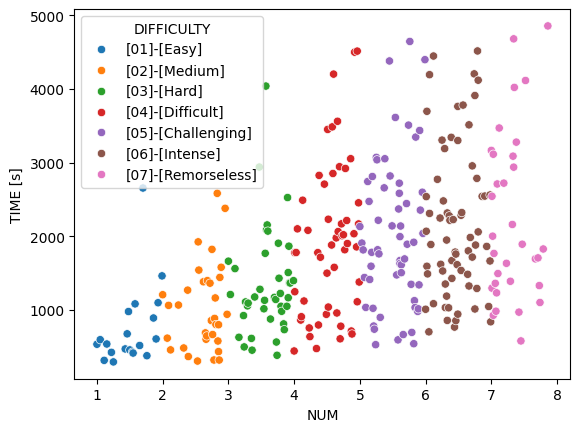

In [ ]:
sns.scatterplot(data=dg,x="NUM",y="TIME [s]",hue="DIFFICULTY")

In [ ]:
r = dg["NUM"].corr(dg["TIME [s]"])
print(f"r = {r}")

r = 0.4593369195751736


In [ ]:
r = df["NUM"].corr(df["TIME [s]"])
print(f"r = {r}")

r = 0.42218552580045493


In [ ]:
cohad = df.drop(index = 0)
print(cohad)

     RANK    #                             TOWER ACRONYM  WLD      AREA  \
1     296   65           Tower of Six Feet Under   ToSFU    2   Zone 03   
2     323    7     Steeple of Beginner's Journey    SoBJ    1  Ring 02B   
3     302   13        Tower of Zero Disturbances    ToZD    2   Zone 01   
4     316    6  Steeple of Meaningless Decisions    SoMD    1  Ring 01B   
5     325    1            Tower of A Simple Time   ToAST    1   Ring 01   
..    ...  ...                               ...     ...  ...       ...   
320   161  308       Tower of Uncontrollable Ire    ToUI    2   Zone 07   
321   206  294                Tower of No Return    ToNR    2   Zone 08   
322   228  286            Tower of Rhythm Heaven    ToRH    1  Ring 06B   
323   144  287      Tower of Mechanical Disarray    ToMD    1  Ring 06B   
324    21  288               Tower of Power Laws    ToPL    2   Zone 10   

             DIFFICULTY   NUM      TIME  TIME [s]      COMPLETION DATE  
1           [01]-[Easy]  1

<Axes: xlabel='NUM', ylabel='TIME [s]'>

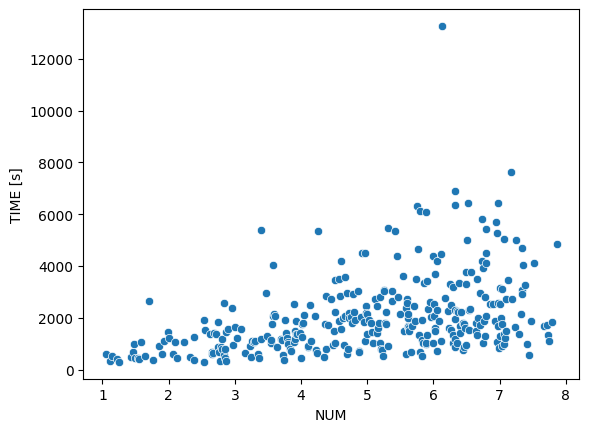

In [ ]:
sns.scatterplot(data=cohad,x="NUM",y="TIME [s]")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RANK             325 non-null    int64  
 1   #                325 non-null    int64  
 2   TOWER            325 non-null    str    
 3   ACRONYM          325 non-null    str    
 4   WLD              325 non-null    int64  
 5   AREA             325 non-null    str    
 6   DIFFICULTY       325 non-null    str    
 7   NUM              325 non-null    float64
 8   TIME             325 non-null    str    
 9   TIME [s]         325 non-null    float64
 10  COMPLETION DATE  325 non-null    str    
dtypes: float64(2), int64(3), str(6)
memory usage: 53.1 KB


In [ ]:
# Copy-pasted from Gemini
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Directly use the exact path for the 'Towers (1)' file
file_path = 'rollrcoast.csv'

print(f"Loading specific dataset copy: {file_path}")
df = pd.read_csv(file_path)

# 2. Define columns and ensure numeric formats
x_col = 'NUM'
y_col = 'TIME [s]'

# Convert columns to numeric, converting errors to NaN, then drop rows with NaNs
df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
df_clean = df.dropna(subset=[x_col, y_col])

x = df_clean[x_col]
y = df_clean[y_col]

# 3. Calculate Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# 4. Output Results

def linRegression(n):
    time = slope * n + intercept
    return time

print("\n" + "="*40)
print("          LINEAR REGRESSION RESULTS")
print("="*40)
print(f"R-value (Correlation Coefficient): {r_value:.4f}")
print(f"R-squared (Coefficient of Det.):  {r_value**2:.4f}")
print(f"Linear Equation: TIME [s] = {slope:.4f} * NUM + {intercept:.4f}")
print("="*40)
n = 7.20
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 7.68
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")
n = 8.00
minutes = linRegression(n)//60
print(f"For a tower with a difficulty of {n:.2f}, the tower is expected to be beaten with a time of {linRegression(n):.2f} seconds, or {minutes:.0f}:{linRegression(n)-minutes*60:.2f}.")

# 5. Create the Visualization
plt.figure(figsize=(10, 6))

# Plot the individual data points
plt.scatter(x, y, color='#1f77b4', alpha=0.6, edgecolors='w', s=40, label='Data Points')

# Plot the fitted regression line
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color='#d62728', linewidth=2.5, 
         label=f'Regression Line\n(y = {slope:.3f}x + {intercept:.3f})')

# Labeling and styling the plot
plt.title('Linear Regression: Time vs Difficulty', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Difficulty (NUM)', fontsize=12)
plt.ylabel('Time (TIME [s])', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Tight layout to avoid overlapping or clipping
plt.tight_layout()
plt.show()